# 02 — Data Quality Assessment

Quality audit of the Jane Street training data, complementing notebook 01:

- **Null percentage per feature over time** (`date_id`) to see whether missingness is stationary.
- **Per-symbol missingness** to detect symbol-specific data gaps.
- **Weight distribution** of the evaluation sample weight.
- **Feature tag matrix** from `features.csv` to expose structural feature groupings.

Tabular artifacts are written to `results/dataset/`, figures to `results/figures/`.

In [1]:
from pathlib import Path

import numpy as np
import polars as pl

import matplotlib.pyplot as plt

from IPython.display import display

from loguru import logger

PROJECT_ROOT = Path.cwd().parents[0]

DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "jane"

TRAIN_DIR = DATA_ROOT / "train.parquet"
FEATURES_FILE = DATA_ROOT / "features.csv"

OUTPUT_DIR = PROJECT_ROOT / "results" / "dataset"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

train = pl.scan_parquet(TRAIN_DIR / "**" / "*.parquet")

feature_cols = [f"feature_{i:02d}" for i in range(79)]

logger.info("Scanning train data from {}", TRAIN_DIR)

2026-07-27 19:24:29.667 | INFO     | __main__:<module>:29 - Scanning train data from D:\distribution-free-sequential-learning\data\raw\jane\train.parquet


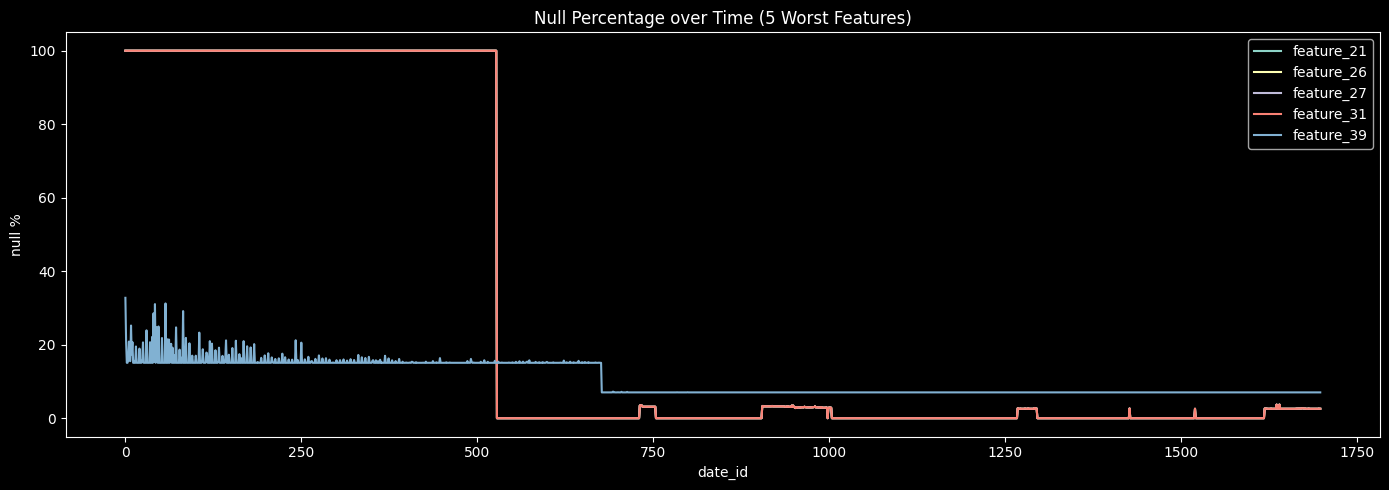

In [2]:
# Null percentage per feature over time (grouped by date_id).
null_by_date = (
    train
    .group_by("date_id")
    .agg(
        pl.len().alias("rows"),
        *[pl.col(c).null_count().alias(c) for c in feature_cols],
    )
    .sort("date_id")
    .collect()
)

null_pct_by_date = null_by_date.with_columns(
    [(pl.col(c) / pl.col("rows") * 100).alias(c) for c in feature_cols]
)

null_pct_by_date.write_csv(OUTPUT_DIR / "null_pct_by_date.csv")

overall_null_pct = {
    c: float(null_by_date[c].sum()) / float(null_by_date["rows"].sum()) * 100
    for c in feature_cols
}
worst = sorted(overall_null_pct, key=overall_null_pct.get, reverse=True)[:5]

plt.figure(figsize=(14, 5))

for c in worst:
    plt.plot(
        null_pct_by_date["date_id"].to_numpy(),
        null_pct_by_date[c].to_numpy(),
        label=c,
    )

plt.title("Null Percentage over Time (5 Worst Features)")
plt.xlabel("date_id")
plt.ylabel("null %")
plt.legend()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "null_pct_over_time.png", dpi=300)

plt.show()

In [ ]:
# Missingness per symbol, averaged over all 79 features.
null_by_symbol = (
    train
    .group_by("symbol_id")
    .agg(
        pl.len().alias("rows"),
        *[pl.col(c).null_count().alias(c) for c in feature_cols],
    )
    .sort("symbol_id")
    .collect()
)

symbol_missing = null_by_symbol.select(
    "symbol_id",
    (
        pl.sum_horizontal([pl.col(c) for c in feature_cols])
        / (pl.col("rows") * len(feature_cols))
        * 100
    ).alias("null_pct"),
)

display(symbol_missing.sort("null_pct", descending=True).head(10))

symbol_missing.write_csv(OUTPUT_DIR / "symbol_missingness.csv")

plt.figure(figsize=(12, 4))

plt.bar(
    symbol_missing["symbol_id"].to_numpy(),
    symbol_missing["null_pct"].to_numpy(),
)

plt.title("Average Feature Missingness per Symbol")
plt.xlabel("symbol_id")
plt.ylabel("null %")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "symbol_missingness.png", dpi=300)

plt.show()

In [ ]:
# Distribution of the evaluation sample weight.
weights = (
    train
    .select("weight")
    .collect()["weight"]
    .to_numpy()
    .astype(np.float64)
)

weight_stats = pl.DataFrame({
    "Metric": ["count", "min", "mean", "median", "max", "std", "share_positive"],
    "Value": [
        float(weights.size),
        float(weights.min()),
        float(weights.mean()),
        float(np.median(weights)),
        float(weights.max()),
        float(weights.std()),
        float((weights > 0).mean()),
    ],
})

display(weight_stats)

weight_stats.write_csv(OUTPUT_DIR / "weight_stats.csv")

plt.figure(figsize=(10, 4))

plt.hist(weights, bins=100)

plt.title("Sample Weight Distribution")
plt.xlabel("weight")
plt.ylabel("count")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "weight_distribution.png", dpi=300)

plt.show()

In [ ]:
# Feature tag matrix from features.csv (structural feature groupings).
tags = pl.read_csv(FEATURES_FILE)

display(tags.head())

tag_cols = [c for c in tags.columns if c != "feature"]
tag_matrix = tags.select(tag_cols).to_numpy().astype(np.float64)

tag_counts = pl.DataFrame({
    "tag": tag_cols,
    "features_tagged": tag_matrix.sum(axis=0).astype(int).tolist(),
})

display(tag_counts)

tag_counts.write_csv(OUTPUT_DIR / "feature_tag_counts.csv")

plt.figure(figsize=(8, 14))

plt.imshow(tag_matrix, aspect="auto", cmap="viridis", interpolation="nearest")

plt.title("Feature Tag Matrix (features.csv)")
plt.xlabel("tag")
plt.ylabel("feature index")
plt.xticks(range(len(tag_cols)), tag_cols, rotation=90)
plt.colorbar(label="tag active")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "feature_tag_matrix.png", dpi=300)

plt.show()

In [ ]:
# --- Heavy-Tail Evidence: Excess Kurtosis ---
# Excess kurtosis κ > 0 means heavier-than-Gaussian tails.
# Features with κ >> 10 produce extreme gradients during OGD that wipe out
# progress accumulated over thousands of steps — the core motivation for RobustOMD.

discrete_cols = {"feature_09", "feature_10", "feature_11"}
float_cols = [c for c in feature_cols if c not in discrete_cols]

kurt_row = train.select([
    pl.col(c).cast(pl.Float64).kurtosis(fisher=True, bias=True).alias(c)
    for c in float_cols
]).collect()

kurtosis_records = [
    {
        "feature": c,
        "excess_kurtosis": float(kurt_row[c][0]) if kurt_row[c][0] is not None else float("nan"),
    }
    for c in float_cols
]
kurtosis_df = pl.DataFrame(kurtosis_records).sort("excess_kurtosis", descending=True)
kurtosis_df.write_csv(OUTPUT_DIR / "feature_kurtosis.csv")
display(kurtosis_df.head(10))

n_heavy  = int((kurtosis_df["excess_kurtosis"] > 10).sum())
n_super  = int((kurtosis_df["excess_kurtosis"] > 100).sum())
logger.info(
    f"Excess kurtosis — median: {kurtosis_df['excess_kurtosis'].median():.2f}, "
    f"features κ>10: {n_heavy}, features κ>100: {n_super}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ks = kurtosis_df["excess_kurtosis"].to_numpy()
axes[0].hist(np.clip(ks, -10, 200), bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Gaussian baseline (κ=0)")
axes[0].set_xlabel("Excess kurtosis (clipped at 200 for display)")
axes[0].set_ylabel("# features")
axes[0].set_title(
    f"Excess kurtosis across {len(float_cols)} continuous features\n"
    f"({n_heavy} with κ>10; {n_super} with κ>100)"
)
axes[0].legend()

top20 = kurtosis_df.head(20)
axes[1].barh(top20["feature"].to_list()[::-1], top20["excess_kurtosis"].to_list()[::-1], color="coral")
axes[1].axvline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("Excess kurtosis")
axes[1].set_title("Top-20 features by excess kurtosis")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_kurtosis.png", dpi=200)
plt.show()


In [ ]:
# --- Heavy-Tail Evidence: Hill Tail-Index Estimator ---
# Hill estimator α: P(|X| > x) ~ x^{-α}.
# α < 2 → infinite variance; 2 ≤ α < 4 → finite variance, infinite 4th moment.
# Our RobustOMD requires only finite variance (α > 2); standard clipping analyses
# (e.g. Cutkosky & Mehta 2021) additionally need α > 4. Features with 2 < α < 4
# fall exactly in the "distribution-free win" regime.

def hill_estimator(arr: np.ndarray, k: int = 1000) -> float:
    arr_abs = np.abs(arr[np.isfinite(arr)])
    arr_sorted = np.sort(arr_abs)[::-1]
    k = min(k, len(arr_sorted) - 1)
    if k <= 0:
        return float("nan")
    log_ratios = np.log(arr_sorted[:k] / (arr_sorted[k] + 1e-300))
    alpha = float(k / np.sum(log_ratios))
    return alpha if np.isfinite(alpha) else float("nan")

# Sample from first 3 date-partitions (~6 M rows) for tractability
extreme_features = (
    kurtosis_df.head(8)["feature"].to_list()
    + ["feature_47", "feature_48", "feature_71"]
)
extreme_features = list(dict.fromkeys(extreme_features))[:10]

hill_records = []
for col in extreme_features:
    arr = (
        train
        .filter(pl.col("date_id") < 510)
        .select(col)
        .collect()
        .get_column(col)
        .drop_nulls()
        .to_numpy()
        .astype(np.float64)
    )
    alpha = hill_estimator(arr)
    hill_records.append({
        "feature": col,
        "tail_index_alpha": round(alpha, 3),
        "finite_variance": bool(alpha > 2),
        "finite_4th_moment": bool(alpha > 4),
    })
    logger.info(f"{col}: α={alpha:.2f}  finite_var={alpha > 2}  finite_4th={alpha > 4}")

hill_df = pl.DataFrame(hill_records).sort("tail_index_alpha")
hill_df.write_csv(OUTPUT_DIR / "feature_tail_index.csv")
display(hill_df)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["crimson" if a < 4 else "steelblue" for a in hill_df["tail_index_alpha"].to_list()]
ax.barh(hill_df["feature"].to_list(), hill_df["tail_index_alpha"].to_list(), color=colors)
ax.axvline(2, color="red",    linestyle="--", linewidth=1.5, label="α=2 (finite-variance threshold)")
ax.axvline(4, color="orange", linestyle="--", linewidth=1.5, label="α=4 (finite 4th-moment threshold)")
ax.set_xlabel("Tail index α (Hill estimator, upper tail)")
ax.set_title(
    "Tail heaviness of 10 highest-kurtosis features\n"
    "(crimson = α < 4: finite-variance but infinite-4th-moment regime — "
    "standard gradient-clipping theory inapplicable)"
)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "feature_tail_index.png", dpi=200)
plt.show()
